# Regime Change Detection Feature Engineering

**Author:** Sergej Schweizer

---
This notebook loads merged BTC spot and perpetual market data return and volatility features, and explores volatility regime behavior with plots.

In [12]:
!pip install -r requirements.txt

In [1]:
# Import pandas for data handling and numpy for numerical feature calculations.
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta, timezone


from deribit_utils import generate_merged_deribit_dataset

In [2]:
end_dt = datetime.now(timezone.utc)
start_dt = end_dt - timedelta(days=365*5)

csv_path = Path("deribit_data.csv")

if csv_path.exists():
    df = pd.read_csv(csv_path, parse_dates=["timestamp"])
    df.set_index('timestamp', inplace=True)
else:
    df = generate_merged_deribit_dataset(
        base_asset="BTC",
        start_dt=start_dt,
        end_dt=end_dt,
        ohlcv_resolution="60",
        funding_resolution="8h",
        spot_chunk_days=7,
        perp_chunk_days=7,
        funding_chunk_days=30,
        save_csv=True,
        csv_path=str(csv_path),
        dropna_subset=['close_spot', 'close_perp']
    )
    df.to_csv("deribit_data.csv")

df.head(3)

,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,volume_perp,cost_perp,index_price,interest_8h,interest_1h,prev_index_price
timestamp,,,,,,,,,,,,,,,,
2023-12-12 12:00:00+00:00,41819.99,41819.99,41819.99,41819.99,0.0112,468.383888,41590.5,41903.0,41590.5,41845.5,284.684758,11895930.0,41575.99,0.000083,9.306260e-07,41801.40
2023-12-12 13:00:00+00:00,41900.00,41900.00,41791.98,41870.00,3.1823,133157.488249,41855.0,42059.5,41752.0,41815.5,583.245790,24440950.0,41842.93,0.000066,7.146489e-06,41575.99
2023-12-12 14:00:00+00:00,41729.96,41730.00,41729.96,41730.00,0.0567,2366.090988,41815.0,41875.5,41301.0,41472.0,1110.233834,46157810.0,41798.09,0.000057,8.726458e-06,41842.93


In [3]:
# Compute log returns plus absolute and squared features for the core price series.
df = df.assign(
    # Spot close-to-close log return.
    return_close_spot=lambda x: np.log(x["close_spot"] / x["close_spot"].shift(1)),
    # Perpetual close-to-close log return.
    return_close_perp=lambda x: np.log(x["close_perp"] / x["close_perp"].shift(1)),
    # Index price log return.
    return_index_price=lambda x: np.log(x["index_price"] / x["index_price"].shift(1)),
    # Absolute spot return as a simple volatility proxy.
    abs_return_close_spot=lambda x: x["return_close_spot"].abs(),
    # Absolute perpetual return as a simple volatility proxy.
    abs_return_close_perp=lambda x: x["return_close_perp"].abs(),
    # Absolute index return as a simple volatility proxy.
    abs_return_index_price=lambda x: x["return_index_price"].abs(),
    # Squared spot return for variance-style features.
    sq_return_close_spot=lambda x: x["return_close_spot"] ** 2,
    # Squared perpetual return for variance-style features.
    sq_return_close_perp=lambda x: x["return_close_perp"] ** 2,
    # Squared index return for variance-style features.
    sq_return_index_price=lambda x: x["return_index_price"] ** 2,
)

In [4]:
# Define the return-based features for which rolling volatility will be calculated.
return_cols = [
    "return_close_spot",
    "return_close_perp",
    "return_index_price",
    "abs_return_close_spot",
    "abs_return_close_perp",
    "abs_return_index_price",
    "sq_return_close_spot",
    "sq_return_close_perp",
    "sq_return_index_price",
]

# Use 24 and 72 hourly observations as short- and medium-horizon rolling windows.
window_24h = 24
window_72h = 72

# Add rolling standard deviation features for each return-derived series.
df = df.assign(
    **{
        f"std_24h_{col}": df[col].rolling(window_24h).std()
        for col in return_cols
    },
    **{
        f"std_72h_{col}": df[col].rolling(window_72h).std()
        for col in return_cols
    },
)

In [5]:
# Build true-range-based ATR features for spot and perpetual BTC markets.
df = df.assign(
    # Spot true range uses the largest move among intraperiod range and gaps from the previous close.
    tr_spot=pd.concat(
        [
            df["high_spot"] - df["low_spot"],
            (df["high_spot"] - df["close_spot"].shift(1)).abs(),
            (df["low_spot"] - df["close_spot"].shift(1)).abs(),
        ],
        axis=1,
    ).max(axis=1),
    # Perpetual true range applies the same definition to perpetual futures prices.
    tr_perp=pd.concat(
        [
            df["high_perp"] - df["low_perp"],
            (df["high_perp"] - df["close_perp"].shift(1)).abs(),
            (df["low_perp"] - df["close_perp"].shift(1)).abs(),
        ],
        axis=1,
    ).max(axis=1),
).assign(
    # Convert true range into 24h and 72h ATR levels, then normalize by price for comparability.
    ATR_24h_spot=lambda x: x["tr_spot"].rolling(24).mean(),
    ATR_72h_spot=lambda x: x["tr_spot"].rolling(72).mean(),
    ATR_24h_spot_norm=lambda x: x["ATR_24h_spot"] / x["close_spot"],
    ATR_72h_spot_norm=lambda x: x["ATR_72h_spot"] / x["close_spot"],
    ATR_24h_perp=lambda x: x["tr_perp"].rolling(24).mean(),
    ATR_72h_perp=lambda x: x["tr_perp"].rolling(72).mean(),
    ATR_24h_perp_norm=lambda x: x["ATR_24h_perp"] / x["close_perp"],
    ATR_72h_perp_norm=lambda x: x["ATR_72h_perp"] / x["close_perp"],
).drop(columns=["tr_spot", "tr_perp"])

In [9]:
df.to_csv("deribit_enriched_data.csv")

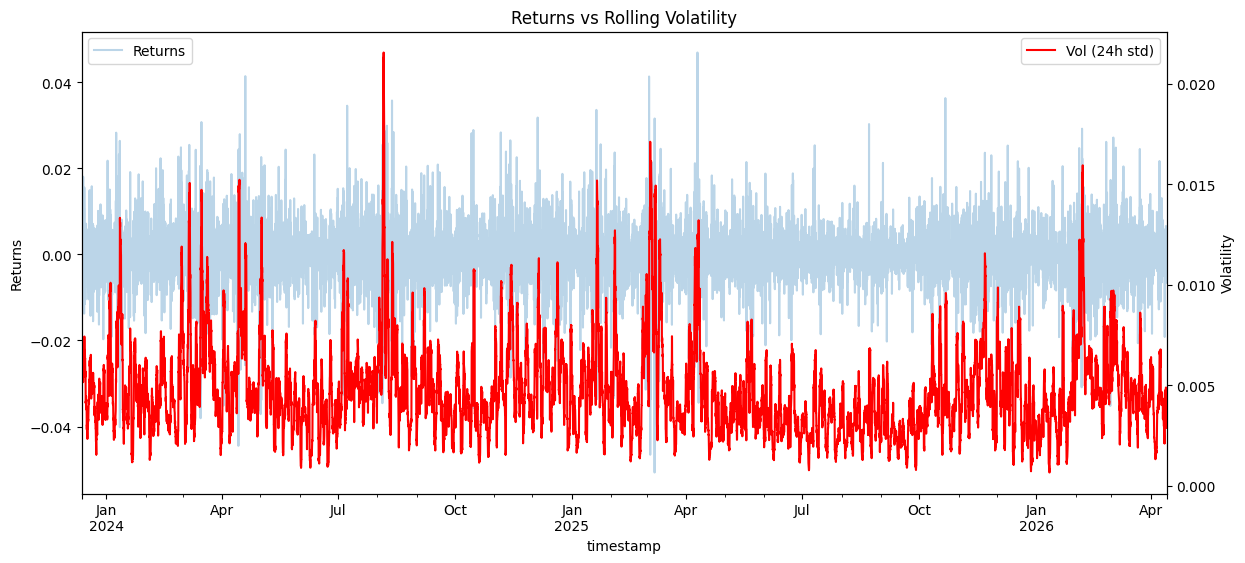

In [6]:
# Plot spot returns against rolling 24-hour volatility to compare price moves with their local variability.
import matplotlib.pyplot as plt

ax1 = df["return_close_spot"].plot(
    figsize=(14, 6),
    alpha=0.3,
    label="Returns",
    ylabel="Returns",
)

ax2 = df["std_24h_return_close_spot"].plot(
    ax=ax1.twinx(),
    color="red",
    label="Vol (24h std)",
    ylabel="Volatility",
)

ax1.set_title("Returns vs Rolling Volatility")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()

This plot places hourly BTC returns next to their rolling 24-hour volatility, making it easier to see how market turbulence builds around sharp price moves.

The light blue return series stays centered near zero most of the time, but it occasionally shows large upward or downward jumps. The red volatility line reacts in bursts rather than moving smoothly, with noticeable spikes clustering around the same periods where returns become more extreme. In other words, calm trading conditions are interrupted by short episodes of stress, and those episodes tend to coincide with larger price swings.

Text(0, 0.5, 'Regime')

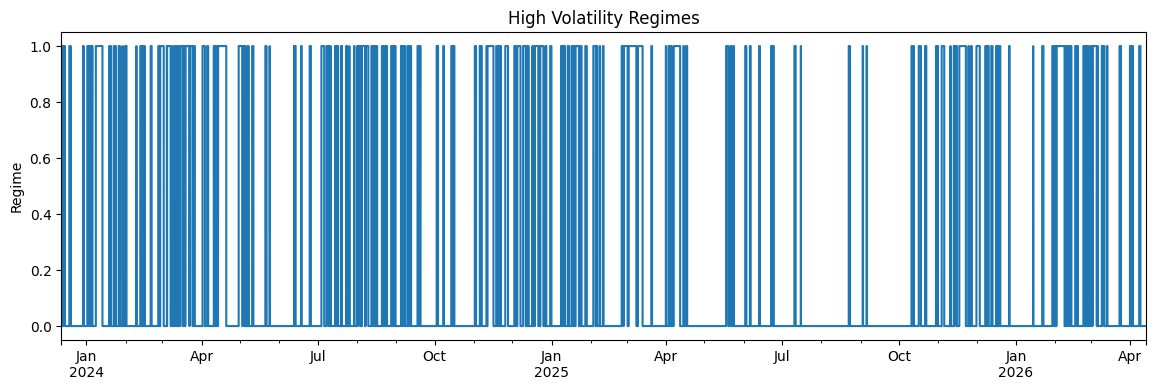

In [7]:
# Label timestamps as high-volatility regimes when 24-hour rolling volatility exceeds its upper quartile.
vol = df["std_24h_return_close_spot"]
threshold = vol.quantile(0.75)

df["high_vol"] = (vol > threshold).astype(int)

ax = df.plot(
    y="high_vol",
    figsize=(14, 4),
    drawstyle="steps",
    title="High Volatility Regimes",
    legend=False,
)

ax.set_xlabel("")
ax.set_ylabel("Regime")

This plot shows when the model classifies the market as being in a high-volatility regime.

A value of `1` marks periods of elevated volatility, while `0` marks more normal conditions. The regime changes happen frequently, which suggests volatility shocks are often abrupt and short-lived rather than long and stable. Still, the denser clusters of `1`s in parts of 2024, early 2025, and again from late 2025 into early 2026 point to broader windows where market stress remains elevated for longer stretches.

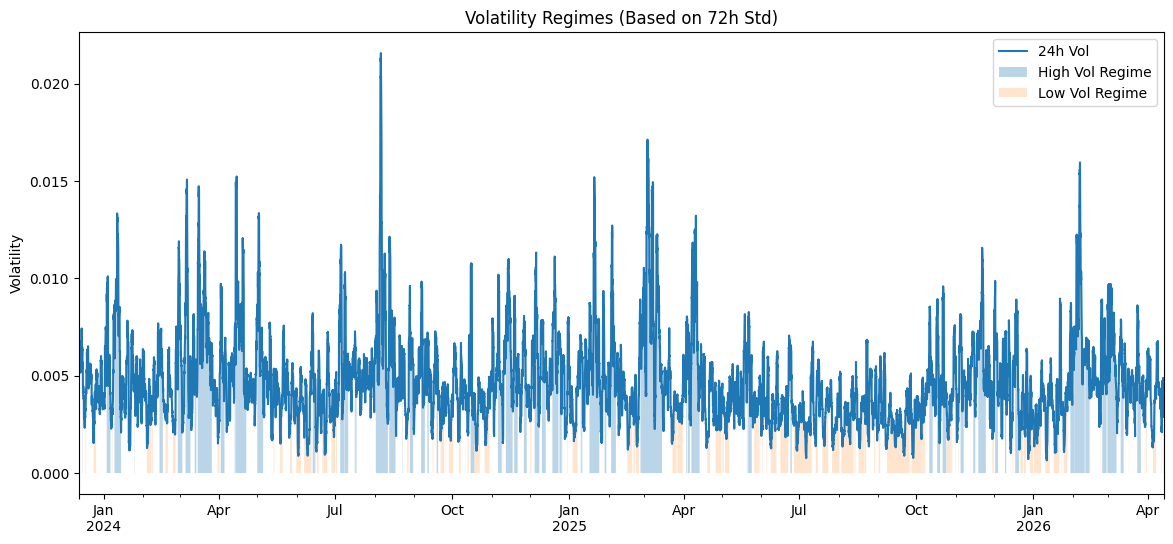

In [8]:
# Highlight high- and low-volatility periods using the 72-hour volatility measure as the regime signal.
vol = df["std_72h_return_close_spot"]
high = vol > vol.quantile(0.75)
low = vol < vol.quantile(0.25)

ax = df.plot(
    y="std_24h_return_close_spot",
    figsize=(14, 6),
    label="24h Vol",
    title="Volatility Regimes (Based on 72h Std)",
)

ax.fill_between(
    df.index,
    0,
    df["std_24h_return_close_spot"],
    where=high,
    alpha=0.3,
    label="High Vol Regime",
)

ax.fill_between(
    df.index,
    0,
    df["std_24h_return_close_spot"],
    where=low,
    alpha=0.2,
    label="Low Vol Regime",
)

ax.set_xlabel("")
ax.set_ylabel("Volatility")
ax.legend()

This graph tracks the evolution of 24-hour volatility and overlays regime labels based on the 72-hour rolling standard deviation.

The blue line shows realized short-term volatility, while the shaded areas separate calmer from more turbulent periods: blue shading marks high-volatility regimes and orange shading marks low-volatility regimes. Most of the series sits in a relatively modest range, but that calm is repeatedly broken by sharp volatility spikes. Those spikes become especially visible around mid-2024, early 2025, and early 2026, highlighting brief but intense episodes of market instability.